<a href="https://colab.research.google.com/github/aiformedresearch/Machine-Learning-for-Bioengineering-2025-26/blob/main/notebooks/age_prediction_eda_regression_holdout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Age Prediction: data preparation, Exploratory Data Analysis (EDA), and regression with hold-out & nested hold-out validation

## Data Preparation and Exploratory Data Analysis (EDA)

Import libraries

In [33]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Loading and showing input (features) and output data (desired output)

In [34]:
df = pd.read_excel('https://raw.githubusercontent.com/sdiciotti/Age-Prediction-Demo/main/NKI2_data.xlsx')
print (type(df))

<class 'pandas.core.frame.DataFrame'>


Print the size of the dataframe

In [35]:
df.shape

(73, 35)

Print the dataframe

In [36]:
print(df)

    Age Sex  cortex_CT  lh_cortex_CT  rh_cortex_CT  lh_frontalGM_CT  \
0    13   F   2.563765       2.53793       2.58960            2.604   
1    13   M   2.816775       2.80403       2.82952            2.870   
2    16   F   2.590785       2.60300       2.57857            2.659   
3    17   M   2.618340       2.62847       2.60821            2.780   
4    17   M   2.737575       2.77298       2.70217            2.866   
..  ...  ..        ...           ...           ...              ...   
68   14   F   2.785335       2.80093       2.76974            2.956   
69   16   M   2.645850       2.62908       2.66262            2.793   
70   12   F   2.731690       2.73606       2.72732            2.854   
71   10   F   2.674965       2.67007       2.67986            2.749   
72   11   M   2.733215       2.74924       2.71719            2.846   

    lh_occipitalGM_CT  lh_temporalGM_CT  lh_parietalGM_CT  rh_frontalGM_CT  \
0               2.084             2.694             2.432            

Check the features and output variables name

In [37]:
features = list(df.columns)
type(features)

list

In [38]:
print(features)

['Age', 'Sex', 'cortex_CT', 'lh_cortex_CT', 'rh_cortex_CT', 'lh_frontalGM_CT', 'lh_occipitalGM_CT', 'lh_temporalGM_CT', 'lh_parietalGM_CT', 'rh_frontalGM_CT', 'rh_occipitalGM_CT', 'rh_temporalGM_CT', 'rh_parietalGM_CT', 'cortex_pial_lgi', 'lh_cortex_pial_lgi', 'rh_cortex_pial_lgi', 'lh_frontal_pial_lgi', 'lh_occipital_pial_lgi', 'lh_temporal_pial_lgi', 'lh_parietal_pial_lgi', 'rh_frontal_pial_lgi', 'rh_occipital_pial_lgi', 'rh_temporal_pial_lgi', 'rh_parietal_pial_lgi', 'cerebralGM_FD', 'lh_cerebralGM_FD', 'lh_frontalGM_FD', 'lh_temporalGM_FD', 'lh_parietalGM_FD', 'lh_occipitalGM_FD', 'rh_cerebralGM_FD', 'rh_frontalGM_FD', 'rh_temporalGM_FD', 'rh_parietalGM_FD', 'rh_occipitalGM_FD']


Plotting some data

Text(0, 0.5, 'cortex CT (mm)')

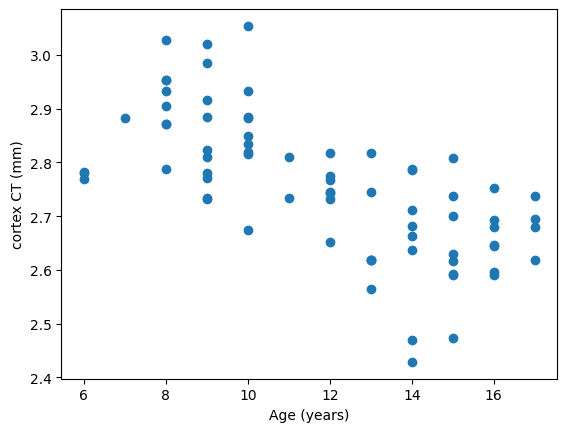

In [39]:
# Plot true vs predicted values to visualize model performance
plt.scatter(df['Age'],df['cortex_CT'])
plt.xlabel('Age (years)')
plt.ylabel('cortex CT (mm)')

In [40]:
print("Dataframe shape before NaN removal:", df.shape)

Dataframe shape before NaN removal: (73, 35)


Removing missing data

In [41]:
df.dropna(axis=0, how='any', inplace=True)
print("Dataframe shape after NaN removal:", df.shape)

Dataframe shape after NaN removal: (72, 35)


Preparing the design matrix X and the desired output y

In [42]:
X = df.iloc[:,2::]
y = df['Age']
print (type(X))
print (type(y))
print (X.shape)
print (y.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
(72, 33)
(72,)


A quick quality control

In [43]:
X.head(6)

,cortex_CT,lh_cortex_CT,rh_cortex_CT,lh_frontalGM_CT,lh_occipitalGM_CT,lh_temporalGM_CT,lh_parietalGM_CT,rh_frontalGM_CT,rh_occipitalGM_CT,rh_temporalGM_CT,...,lh_cerebralGM_FD,lh_frontalGM_FD,lh_temporalGM_FD,lh_parietalGM_FD,lh_occipitalGM_FD,rh_cerebralGM_FD,rh_frontalGM_FD,rh_temporalGM_FD,rh_parietalGM_FD,rh_occipitalGM_FD
0,2.563765,2.53793,2.58960,2.604,2.084,2.694,2.432,2.573,2.213,2.901,...,2.4527,2.3947,2.3795,2.3840,2.2441,2.4524,2.4001,2.3942,2.3788,2.2650
1,2.816775,2.80403,2.82952,2.870,2.265,3.188,2.564,2.914,2.244,3.230,...,2.4719,2.4216,2.4228,2.3896,2.2861,2.5181,2.4290,2.4202,2.3942,2.2631
2,2.590785,2.60300,2.57857,2.659,2.058,2.877,2.537,2.649,2.083,2.787,...,2.4854,2.3733,2.3712,2.3852,2.2485,2.4820,2.3681,2.3633,2.3735,2.2511
3,2.618340,2.62847,2.60821,2.780,2.057,2.867,2.459,2.739,2.129,2.880,...,2.4911,2.4034,2.3956,2.3679,2.2631,2.4535,2.3933,2.3921,2.3683,2.2677
4,2.737575,2.77298,2.70217,2.866,2.137,3.194,2.546,2.716,2.204,3.150,...,2.5081,2.4224,2.4194,2.3738,2.2687,2.4641,2.4074,2.4158,2.3694,2.2728
5,2.752830,2.76857,2.73709,2.825,2.172,3.129,2.593,2.702,2.308,3.185,...,2.5024,2.4062,2.4273,2.3702,2.2810,2.4618,2.3929,2.4225,2.3780,2.3053


In [44]:
print('The whole dataset contains ' + str(X.shape[0]) + ' subjects')
print('The age prediction will be performed using ' + str(X.shape[1]) + ' MRI-derived features')

The whole dataset contains 72 subjects
The age prediction will be performed using 33 MRI-derived features


## Regression task

### Linear Regression using a hold-out validation scheme

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Setting the seed of the random generator
SEED = 42

# Size of the samples in the test set: e.g., 0.1, means that the test set is composed of 10% of the samples of the entire dataset
test_size = 0.1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=SEED)

In [46]:
type(X_train)

pandas.core.frame.DataFrame

In [47]:
type(y_train)

pandas.core.series.Series

In [48]:
# Print the shape of the training and test sets
print (X_train.shape, y_train.shape)
print (X_test.shape, y_test.shape)

(64, 33) (64,)
(8, 33) (8,)


In [49]:
X_train.head(2)

,cortex_CT,lh_cortex_CT,rh_cortex_CT,lh_frontalGM_CT,lh_occipitalGM_CT,lh_temporalGM_CT,lh_parietalGM_CT,rh_frontalGM_CT,rh_occipitalGM_CT,rh_temporalGM_CT,...,lh_cerebralGM_FD,lh_frontalGM_FD,lh_temporalGM_FD,lh_parietalGM_FD,lh_occipitalGM_FD,rh_cerebralGM_FD,rh_frontalGM_FD,rh_temporalGM_FD,rh_parietalGM_FD,rh_occipitalGM_FD
12,2.809385,2.83395,2.78482,2.930,2.131,3.190,2.679,2.911,2.137,3.122,...,2.5204,2.4325,2.4165,2.3813,2.2711,2.5142,2.4264,2.4129,2.3980,2.2782
54,2.711305,2.70106,2.72155,2.923,1.982,3.018,2.502,2.865,1.980,3.124,...,2.4919,2.3981,2.3901,2.3559,2.2668,2.4900,2.3897,2.3798,2.3676,2.2364


In [50]:
y_train.head(2)

,Age
12,9
54,14


In [51]:
# Calculate the Mean Absolute Error (MAE) to evaluate model performance
# Fitting the linear model
reg = LinearRegression().fit(X_train, y_train)

# Applying the final model to the test set samples
y_pred = reg.predict(X_test)

# Compute the MAE in the test set
MAE = mean_absolute_error(y_test, y_pred)
print ("MAE test set:", MAE, "years")

MAE test set: 1.4109915646679987 years


In [52]:
type(y_pred)

numpy.ndarray

### Polynomial regression using a nested hold-out validation scheme

In [53]:
from sklearn.model_selection import train_test_split

# Setting the seed of the random generator
SEED = 42

# Size of the samples in the test set: e.g., 0.1, means that the test set is composed of 10% of the samples of the entire dataset
test_size = 0.1

# Size of the samples in the validation set: e.g., 0.1, means that the test set is composed of 10% of the samples of the development set
val_size = 0.1

# Outer hold-out
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=test_size, random_state=SEED)

# Print the size of the development and test sets
print ("The development set size is", "X:", X_dev.shape, "y:", y_dev.shape)
print ("The test set size is", "X:", X_test.shape, "y:", y_test.shape)

# Inner hold-out
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=val_size, random_state=SEED)
# Print the size of the training and validation sets
print ("\nThe development set size is", "X:", X_train.shape, "y:", y_train.shape)
print ("The test set size is", "X:", X_val.shape, "y:", y_val.shape)
print()


The development set size is X: (64, 33) y: (64,)
The test set size is X: (8, 33) y: (8,)

The development set size is X: (57, 33) y: (57,)
The test set size is X: (7, 33) y: (7,)



*** Polynomial degree: 1 MAE: 1.529087405773741
*** Polynomial degree: 2 MAE: 2.0430609668447466
*** Polynomial degree: 3 MAE: 2.0191232825290797
*** Polynomial degree: 4 MAE: 2.0021223995981074
*** Polynomial degree: 5 MAE: 2.0039228394177124

Best polynomial degree: 1 MAE: 1.529087405773741 years
MAE test set: 1.4109915646680058 years


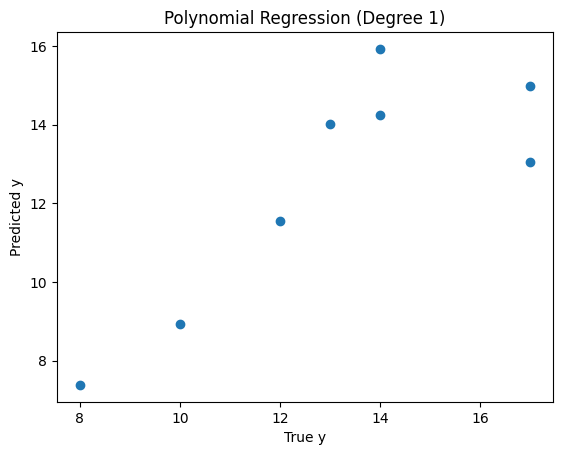

In [54]:
from sklearn.preprocessing import PolynomialFeatures

MAE = []
degree_list = [1, 2, 3, 4, 5]  # List of polynomial degrees to test

for d in degree_list:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    reg = LinearRegression().fit(X_train_poly, y_train)
    y_val_pred = reg.predict(X_val_poly)

    MAE_d = mean_absolute_error(y_val, y_val_pred)
    print("*** Polynomial degree:", d, "MAE:", MAE_d)
    MAE.append(MAE_d)

# Find the best degree with the lowest MAE
best_degree_index = np.argmin(MAE)
best_degree = degree_list[best_degree_index]
print("\nBest polynomial degree:", best_degree, "MAE:", MAE[best_degree_index], "years")

# Re-train the Polynomial Regression model on the development set using the best degree
poly = PolynomialFeatures(degree=best_degree)
X_dev_poly = poly.fit_transform(X_dev)
X_test_poly = poly.transform(X_test)

reg = LinearRegression().fit(X_dev_poly, y_dev)

# Apply the model to the test set and compute the MAE
y_test_pred = reg.predict(X_test_poly)
MAE_test = mean_absolute_error(y_test, y_test_pred)
print("MAE test set:", MAE_test, "years")

# Plot predictions in the test set
plt.scatter(y_test, y_test_pred)
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title(f'Polynomial Regression (Degree {best_degree})')
plt.show()

### Support Vector Regressor with hyperparameter C (Complexity) using a nested hold-out validation scheme

*** C value: 0.1 MAE: 2.744695146993926
*** C value: 1 MAE: 2.157673642649064
*** C value: 10 MAE: 1.7345360725342982

Best C:  10 MAE 1.7345360725342982 years
MAE test set: 1.4109915646679987 years


Text(0, 0.5, 'predicted y')

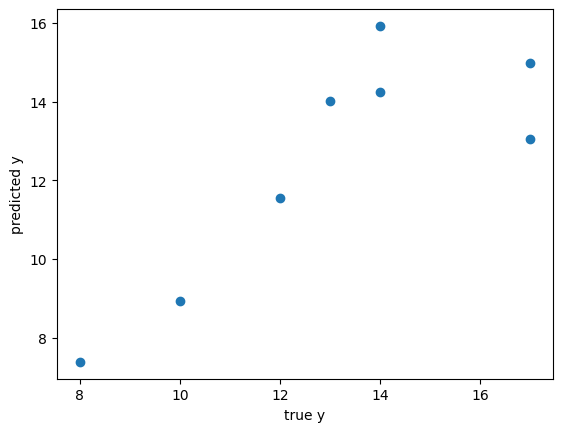

In [55]:

MAE = []
C_list = [0.1, 1, 10]
for c in C_list:
    reg = SVR(kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, C=c, epsilon=0.1, shrinking=True, cache_size=200, verbose=0, max_iter=- 1).fit(X_train, y_train)
    y_val_pred = reg.predict(X_val)
    MAE_c = mean_absolute_error(y_val, y_val_pred)
    print ("*** C value:", c, "MAE:", MAE_c)
    MAE.append (MAE_c)
bestC_index = np.argmin(MAE)
bestC = C_list[bestC_index]
print ("\nBest C: ", bestC, "MAE", MAE[bestC_index], "years")

# Re-train the SVR model in the development test using the bestC hyperparameter
reg = SVR(kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, C=bestC, epsilon=0.1, shrinking=True, cache_size=200, verbose=0, max_iter=- 1).fit(X_dev, y_dev)

# Apply the model to the test set and compute the MAE
y_test_pred = reg.predict(X_test)
MAE = mean_absolute_error(y_test, y_pred)
print ("MAE test set:", MAE, "years")

# Plot predictions in the test set
plt.scatter(y_test,y_pred)
plt.xlabel('true y')
plt.ylabel('predicted y')